## analyzing the automobile dataset

In [885]:
# import required libraries
import pandas as pd
import matplotlib.pyplot as plt

In [ ]:
# read the data file
# had to open it in notepad to understand the syntax
# the file first lists the attributes then the data
with open("automobile.dat") as file:
    
    attributes = []
    data = []
    read_data=False
    for line in file:
        
        if "@attribute" in line:

            # turn each line to a list and add the name of the attribute to our list of attributes
            line_list = line.split()
            attributes.append( line_list[1] )
        
        elif "@data" in line:
            read_data=True

        elif read_data:
            data.append(line.split(","))
            
df = pd.DataFrame(data, columns=attributes)

Lets look at the dataframe

In [887]:
df.head()

,Normalized-losses,Make,Fuel-type,Aspiration,Num-of-doors,Body-style,Drive-wheels,Engine-location,Wheel-base,Length,...,Fuel-system,Bore,Stroke,Compression-ratio,Horsepower,Peak-rpm,City-mpg,Highway-mpg,Price,Symboling
0,168,toyota,gas,std,two,sedan,rwd,front,94.5,168.7,...,2bbl,3.19,3.03,9,70,4800,29,34,8058,1\n
1,113,mazda,gas,std,four,sedan,fwd,front,93.1,166.8,...,2bbl,3.08,3.15,9,68,5000,31,38,7395,1\n
2,87,toyota,gas,std,two,hatchback,fwd,front,95.7,158.7,...,2bbl,3.05,3.03,9,62,4800,35,39,5348,1\n
3,125,mitsubishi,gas,std,four,sedan,fwd,front,96.3,172.4,...,2bbl,3.35,3.46,8.5,88,5000,25,32,6989,1\n
4,148,dodge,gas,turbo,?,sedan,fwd,front,93.7,157.3,...,mpfi,3.03,3.39,7.6,102,5500,24,30,8558,1\n


The data contains ? and Symboling includes "\n"

In [888]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 205 entries, 0 to 204
Data columns (total 26 columns):
 #   Column             Non-Null Count  Dtype 
---  ------             --------------  ----- 
 0   Normalized-losses  205 non-null    object
 1   Make               205 non-null    object
 2   Fuel-type          205 non-null    object
 3   Aspiration         205 non-null    object
 4   Num-of-doors       205 non-null    object
 5   Body-style         205 non-null    object
 6   Drive-wheels       205 non-null    object
 7   Engine-location    205 non-null    object
 8   Wheel-base         205 non-null    object
 9   Length             205 non-null    object
 10  Width              205 non-null    object
 11  Height             205 non-null    object
 12  Curb-weight        205 non-null    object
 13  Engine-type        205 non-null    object
 14  Num-of-cylinders   205 non-null    object
 15  Engine-size        205 non-null    object
 16  Fuel-system        205 non-null    object
 1

Lets clean the data

In [889]:
df["Symboling"] = df["Symboling"].apply(lambda x: x.rstrip("\n")) # removes the \n from each entry

In [890]:
question_mark_counts = df.apply(lambda col: (col == '?').sum())
question_mark_counts

Normalized-losses    41
Make                  0
Fuel-type             0
Aspiration            0
Num-of-doors          2
Body-style            0
Drive-wheels          0
Engine-location       0
Wheel-base            0
Length                0
Width                 0
Height                0
Curb-weight           0
Engine-type           0
Num-of-cylinders      0
Engine-size           0
Fuel-system           0
Bore                  4
Stroke                4
Compression-ratio     0
Horsepower            2
Peak-rpm              2
City-mpg              0
Highway-mpg           0
Price                 4
Symboling             0
dtype: int64

Normalized losses has a lot of missing values, the other columns have a few

In [891]:
# change the ? to NA
df.replace(['?'], pd.NA, inplace=True)

In [892]:
# all columns are dtype object, lets change the relevant ones to numeric

df = df.apply(pd.to_numeric, errors='ignore')
df.head()

C:\Users\jonas\AppData\Local\Temp\ipykernel_48364\3292342271.py:3: FutureWarning: errors='ignore' is deprecated and will raise in a future version. Use to_numeric without passing `errors` and catch exceptions explicitly instead
  df = df.apply(pd.to_numeric, errors='ignore')


,Normalized-losses,Make,Fuel-type,Aspiration,Num-of-doors,Body-style,Drive-wheels,Engine-location,Wheel-base,Length,...,Fuel-system,Bore,Stroke,Compression-ratio,Horsepower,Peak-rpm,City-mpg,Highway-mpg,Price,Symboling
0,168.0,toyota,gas,std,two,sedan,rwd,front,94.5,168.7,...,2bbl,3.19,3.03,9.0,70.0,4800.0,29,34,8058.0,1
1,113.0,mazda,gas,std,four,sedan,fwd,front,93.1,166.8,...,2bbl,3.08,3.15,9.0,68.0,5000.0,31,38,7395.0,1
2,87.0,toyota,gas,std,two,hatchback,fwd,front,95.7,158.7,...,2bbl,3.05,3.03,9.0,62.0,4800.0,35,39,5348.0,1
3,125.0,mitsubishi,gas,std,four,sedan,fwd,front,96.3,172.4,...,2bbl,3.35,3.46,8.5,88.0,5000.0,25,32,6989.0,1
4,148.0,dodge,gas,turbo,<NA>,sedan,fwd,front,93.7,157.3,...,mpfi,3.03,3.39,7.6,102.0,5500.0,24,30,8558.0,1


In [893]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 205 entries, 0 to 204
Data columns (total 26 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Normalized-losses  164 non-null    float64
 1   Make               205 non-null    object 
 2   Fuel-type          205 non-null    object 
 3   Aspiration         205 non-null    object 
 4   Num-of-doors       203 non-null    object 
 5   Body-style         205 non-null    object 
 6   Drive-wheels       205 non-null    object 
 7   Engine-location    205 non-null    object 
 8   Wheel-base         205 non-null    float64
 9   Length             205 non-null    float64
 10  Width              205 non-null    float64
 11  Height             205 non-null    float64
 12  Curb-weight        205 non-null    int64  
 13  Engine-type        205 non-null    object 
 14  Num-of-cylinders   205 non-null    object 
 15  Engine-size        205 non-null    int64  
 16  Fuel-system        205 non

num-of-cylinders and num-of-doors have string entries but we can change them to integers

In [894]:
n_words = ['zero', 'one', 'two', 'three', 'four', 'five', 'six', 'seven', 'eight', 'nine', 'ten', 'eleven', 'twelve']
n_symbols = [x for x in range(13)]
number_dict = dict(zip(n_words, n_symbols))

df["Num-of-cylinders"] = df["Num-of-cylinders"].map(number_dict)
df["Num-of-doors"] = df["Num-of-doors"].map(number_dict)
df

,Normalized-losses,Make,Fuel-type,Aspiration,Num-of-doors,Body-style,Drive-wheels,Engine-location,Wheel-base,Length,...,Fuel-system,Bore,Stroke,Compression-ratio,Horsepower,Peak-rpm,City-mpg,Highway-mpg,Price,Symboling
0,168.0,toyota,gas,std,2.0,sedan,rwd,front,94.5,168.7,...,2bbl,3.19,3.03,9.0,70.0,4800.0,29,34,8058.0,1
1,113.0,mazda,gas,std,4.0,sedan,fwd,front,93.1,166.8,...,2bbl,3.08,3.15,9.0,68.0,5000.0,31,38,7395.0,1
2,87.0,toyota,gas,std,2.0,hatchback,fwd,front,95.7,158.7,...,2bbl,3.05,3.03,9.0,62.0,4800.0,35,39,5348.0,1
3,125.0,mitsubishi,gas,std,4.0,sedan,fwd,front,96.3,172.4,...,2bbl,3.35,3.46,8.5,88.0,5000.0,25,32,6989.0,1
4,148.0,dodge,gas,turbo,NaN,sedan,fwd,front,93.7,157.3,...,mpfi,3.03,3.39,7.6,102.0,5500.0,24,30,8558.0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
200,65.0,toyota,gas,std,4.0,sedan,fwd,front,102.4,175.6,...,mpfi,3.31,3.54,8.7,92.0,4200.0,27,32,10898.0,-1
201,NaN,mercedes-benz,gas,std,4.0,sedan,rwd,front,115.6,202.6,...,mpfi,3.46,3.10,8.3,155.0,4750.0,16,18,34184.0,-1
202,128.0,nissan,gas,std,2.0,sedan,fwd,front,94.5,165.3,...,2bbl,3.15,3.29,9.4,69.0,5200.0,31,37,6649.0,1
203,186.0,porsche,gas,std,2.0,hatchback,rwd,front,94.5,168.9,...,mpfi,3.94,3.11,9.5,143.0,5500.0,19,27,22018.0,3


Lets take a look at the distribututions in the categorical columns

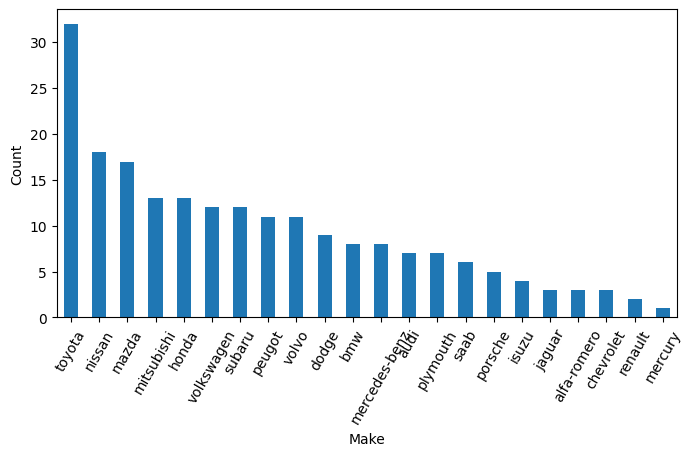

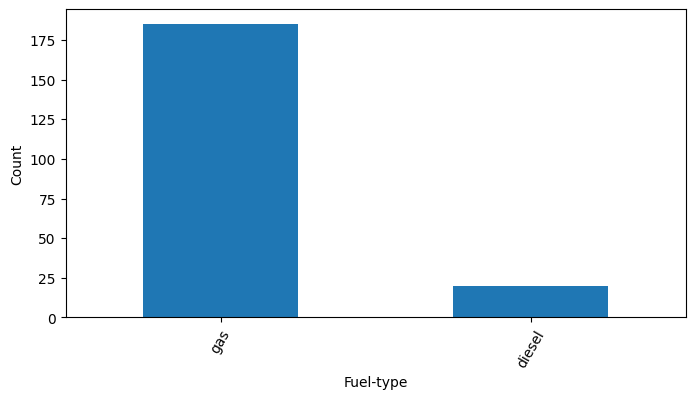

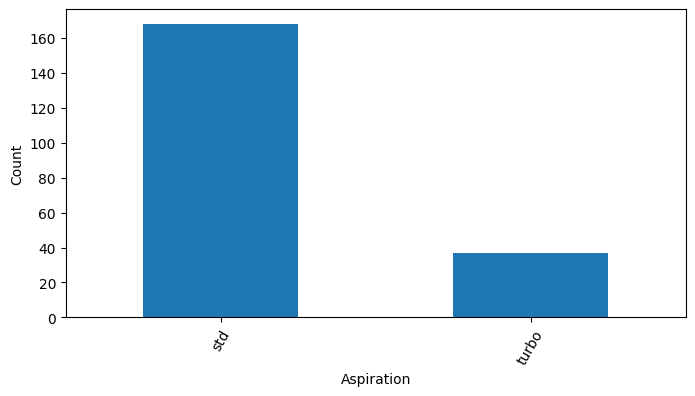

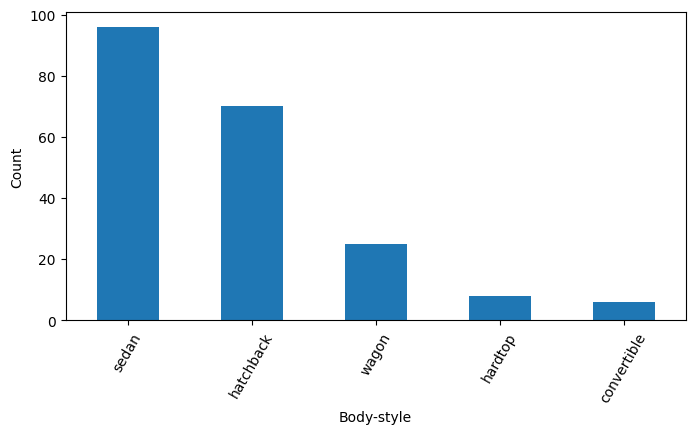

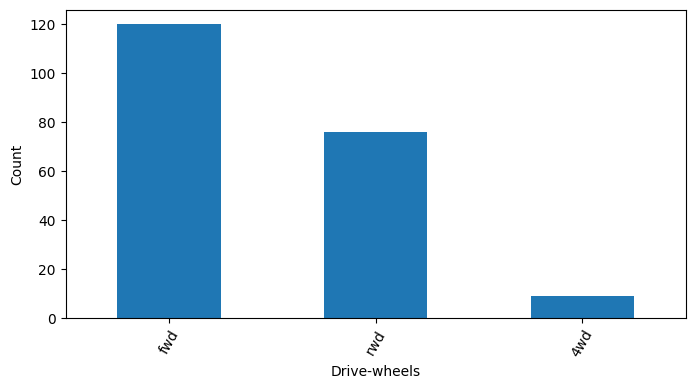

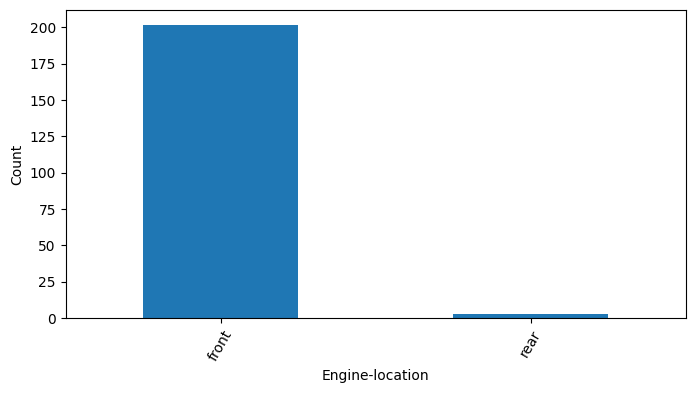

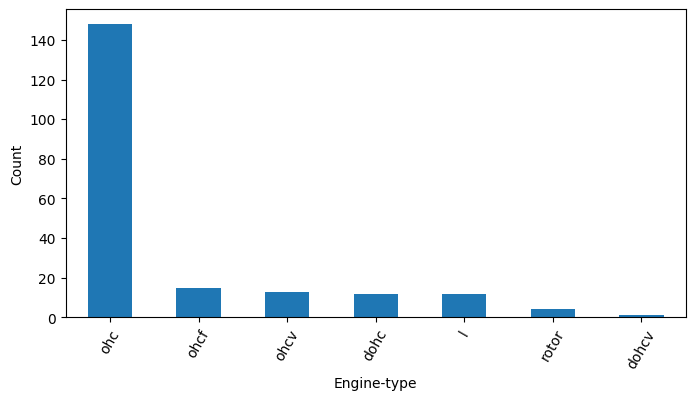

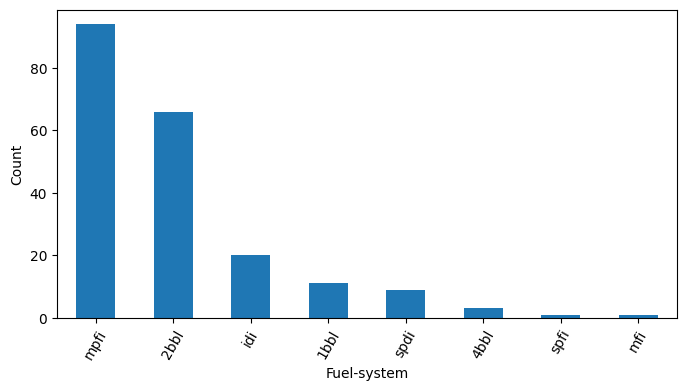

In [895]:
for col in df.select_dtypes(include=['object']):
    counts = df[col].value_counts()
    plt.figure(figsize=(8, 4))
    counts.plot(kind='bar')
    plt.xlabel(col)
    plt.ylabel('Count')
    plt.xticks(rotation=60)
    plt.show()

Lets look at Symboling, which is our target column

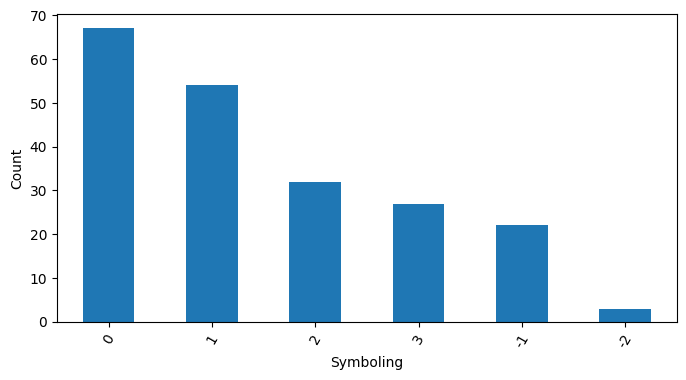

In [896]:
df[col].value_counts()
plt.figure(figsize=(8, 4))
df['Symboling'].value_counts().plot(kind='bar')
plt.xlabel('Symboling')
plt.ylabel('Count')
plt.xticks(rotation=60)
plt.show()

Seems to be very few cars with Symboling of -2

lets look at the correlation between the numerical features

In [897]:
import seaborn as sns

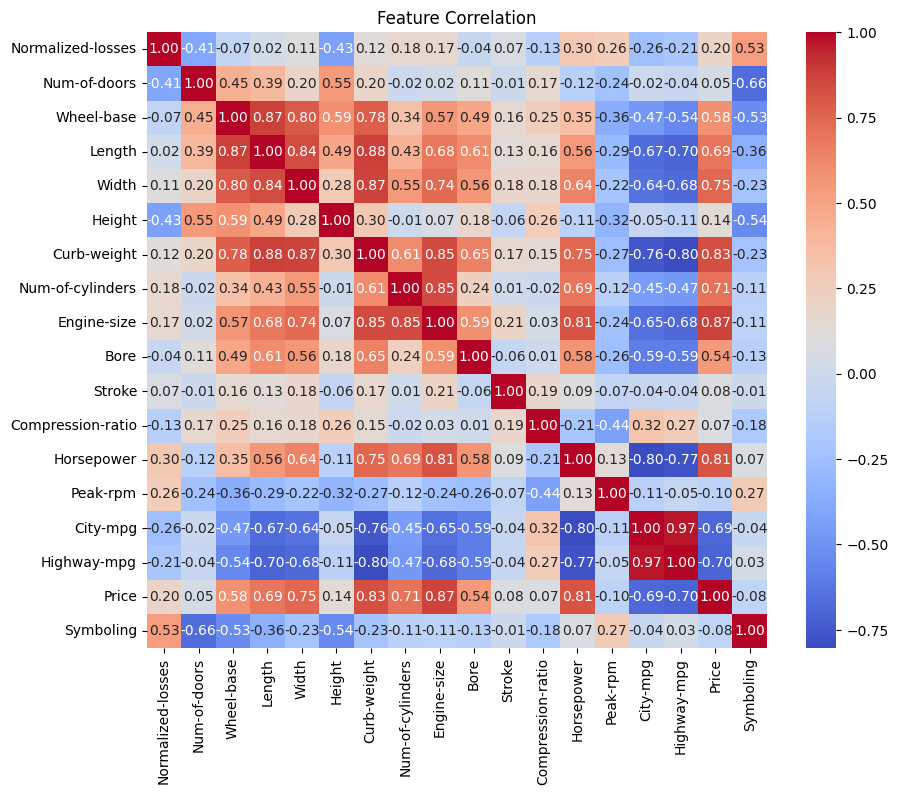

In [898]:
correlation_matrix = df.select_dtypes(include=['float64', 'int64']).corr()

# create a correlation heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Feature Correlation')
plt.show()

lets impute the missing values

we are missing a lot of values in the normalized losses column, instead just imputing the mean, lets use KNNimputing for numerical features, and imputing the mode for categorical features.

Since we are going to use these values for predicting symboling, we must exclude symboling from the imputing process. Symboling has no missing values

In [899]:
from sklearn.impute import KNNImputer

In [900]:
# split the dataset into target and features
y = df['Symboling']
X = df.drop('Symboling', axis=1)

# split into numerical and categorical for doing different types of imputing
numerical_cols = X.select_dtypes(include=['float64', 'int64']).columns
categorical_cols = X.select_dtypes(include=['object']).columns

# impute
knn_imputer = KNNImputer(n_neighbors=5)
numerical_imputed = pd.DataFrame(knn_imputer.fit_transform(X[numerical_cols]), columns=numerical_cols)

categorical_imputed = X[categorical_cols].apply(lambda col: col.fillna(col.mode()[0]))

X = pd.concat([numerical_imputed, categorical_imputed], axis=1)



In [901]:
print(X.isnull().sum())

Normalized-losses    0
Num-of-doors         0
Wheel-base           0
Length               0
Width                0
Height               0
Curb-weight          0
Num-of-cylinders     0
Engine-size          0
Bore                 0
Stroke               0
Compression-ratio    0
Horsepower           0
Peak-rpm             0
City-mpg             0
Highway-mpg          0
Price                0
Make                 0
Fuel-type            0
Aspiration           0
Body-style           0
Drive-wheels         0
Engine-location      0
Engine-type          0
Fuel-system          0
dtype: int64


lets scale the numerical features for optimal training performance

In [902]:
from sklearn.preprocessing import StandardScaler

In [903]:
scaler = StandardScaler()
X[numerical_cols] = scaler.fit_transform(X[numerical_cols])

do one hot encoding on the categorical features

In [904]:
X = pd.get_dummies(X, columns=categorical_cols, dtype='int', drop_first=True) # drop first to avoid colinearity

In [905]:
X.head(10)

,Normalized-losses,Num-of-doors,Wheel-base,Length,Width,Height,Curb-weight,Num-of-cylinders,Engine-size,Bore,...,Engine-type_ohcf,Engine-type_ohcv,Engine-type_rotor,Fuel-system_2bbl,Fuel-system_4bbl,Fuel-system_idi,Fuel-system_mfi,Fuel-system_mpfi,Fuel-system_spdi,Fuel-system_spfi
0,1.425239,-1.139404,-0.708596,-0.434647,-0.891512,-0.461478,-0.744242,-0.352887,-0.695874,-0.506795,...,0,0,0,1,0,0,0,0,0,0
1,-0.276974,0.884667,-0.941655,-0.589028,-0.798053,0.153893,-1.165875,-0.352887,-0.864383,-0.912310,...,0,0,0,1,0,0,0,0,0,0
2,-1.081656,-1.139404,-0.508831,-1.247182,-1.078431,0.317992,-1.098491,-0.352887,-0.840310,-1.022905,...,0,0,0,1,0,0,0,0,0,0
3,0.094418,0.884667,-0.408949,-0.134009,-0.237296,-0.871725,-0.366890,-0.352887,-0.118132,0.083045,...,0,0,0,1,0,0,0,0,0,0
4,0.806252,0.479853,-0.841772,-1.360937,-0.984972,-1.281972,-0.701886,-0.352887,-0.695874,-1.096635,...,0,0,0,0,0,0,0,1,0,0
5,0.868151,-1.139404,-0.575419,-0.410271,-0.097107,-1.692220,-0.338011,-2.207806,-1.369907,-0.484676,...,0,0,1,0,1,0,0,0,0,0
6,2.229921,-1.139404,-1.241301,-0.272140,0.930947,-1.651195,1.123266,1.502032,1.302152,0.377965,...,0,1,0,0,0,0,0,1,0,0
7,-0.270784,-1.139404,0.539933,1.434184,2.192650,-2.430664,2.684657,7.066788,4.792679,0.783480,...,0,1,0,0,0,0,0,1,0,0
8,0.187266,0.884667,0.273580,0.621649,0.276731,0.564140,1.038554,1.502032,1.302152,0.377965,...,0,1,0,0,0,0,0,1,0,0
9,1.208593,0.884667,1.522109,1.027916,1.164596,1.220535,1.340821,-0.352887,0.604046,1.373321,...,0,0,0,0,0,1,0,0,0,0


Now the data cleaning is finished

lets start unsupervised learning

# hierachial clustering

In [906]:
# import libraries
from sklearn.cluster import AgglomerativeClustering
import scipy.cluster.hierarchy as sch

We will use agglomerative clustering with ward linkage, and Euclidean distance

Lets look at the dendrogram

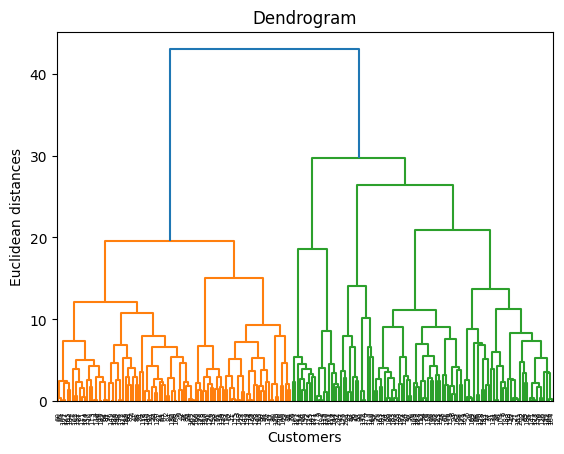

In [907]:
dendrogram = sch.dendrogram(sch.linkage(X, method  = "ward"))

plt.title('Dendrogram')
plt.xlabel('Customers')
plt.ylabel('Euclidean distances')
plt.show()

we pick 6 clusters because symboling can take 6 different values

In [908]:
hc = AgglomerativeClustering(n_clusters = 6, metric = 'euclidean', linkage ='ward')
y_hc = hc.fit_predict(X)

In [909]:
y_hc

array([5, 5, 5, 2, 5, 3, 3, 1, 4, 0, 5, 2, 3, 5, 2, 5, 2, 2, 3, 1, 4, 5,
       3, 2, 5, 5, 3, 3, 2, 1, 4, 3, 4, 1, 5, 3, 4, 0, 4, 3, 3, 5, 5, 1,
       5, 4, 3, 3, 5, 2, 2, 2, 2, 1, 4, 0, 0, 4, 4, 5, 5, 4, 4, 5, 5, 5,
       5, 5, 3, 3, 4, 5, 0, 2, 4, 2, 3, 3, 4, 4, 2, 5, 3, 4, 5, 5, 5, 5,
       5, 5, 1, 2, 2, 2, 4, 2, 1, 5, 2, 2, 2, 0, 5, 4, 3, 5, 3, 5, 4, 3,
       1, 5, 0, 5, 2, 0, 0, 4, 5, 4, 2, 4, 5, 4, 4, 4, 3, 5, 3, 5, 5, 3,
       1, 2, 2, 0, 0, 2, 4, 2, 5, 3, 3, 2, 0, 5, 5, 4, 2, 5, 3, 3, 5, 2,
       0, 2, 2, 5, 3, 0, 2, 0, 4, 4, 3, 5, 1, 0, 5, 3, 1, 0, 5, 0, 5, 1,
       2, 3, 2, 2, 4, 4, 3, 3, 5, 5, 5, 3, 4, 5, 3, 4, 4, 2, 0, 2, 4, 5,
       4, 2, 2, 1, 5, 3, 0])

Lets score the clustering with silhoutte and rand score

In [910]:
from sklearn.metrics import silhouette_score, adjusted_rand_score

In [ ]:
silh_avg = silhouette_score(X, y_hc)
ars_avg = adjusted_rand_score(df['Symboling'], y_hc)

In [912]:
print(silh_avg)
print(ars_avg)

0.1647215992913236
0.17365979331712003


We didnt score especialy good, but we dont have anything to compare the scores to either

Lets see if there is any correlation between the assigned label and the Symboling

We can do this even though symboling is categorical because it is ordinal

<Axes: xlabel='Label'>

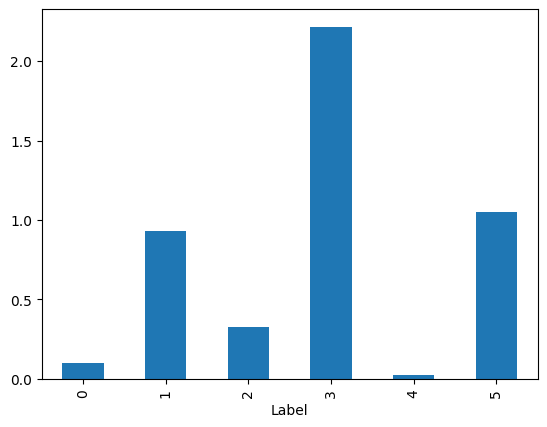

In [ ]:
# add the predicted label to the set
X['Label'] = y_hc

# group X by the predicted label and find the mean Symboling for each label
X_grouped = X
X_grouped['Symboling'] = df['Symboling']
X_grouped=X.groupby('Label')
X_grouped['Symboling'].mean().plot.bar()

There seems to be a correlation between the assigned labels and the symboling value, those with label 3 seem to have an especially high symboling value while those with label 4 have a low one

# classification

lets do dummy classifier first to get a baseline

In [914]:
from sklearn.dummy import DummyClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report
from sklearn.metrics import ConfusionMatrixDisplay

In [915]:
# split into training and testing
xTrain, xTest, yTrain, yTest = train_test_split(X, df['Symboling'], test_size=0.2, random_state=1)

In [916]:
dum = DummyClassifier(strategy='stratified')
dum.fit(xTrain, yTrain)
dumPred = dum.predict(xTest)
print(classification_report(yTest, dumPred))

              precision    recall  f1-score   support

          -2       0.00      0.00      0.00         1
          -1       0.25      0.20      0.22         5
           0       0.22      0.33      0.27        12
           1       0.09      0.14      0.11         7
           2       0.20      0.12      0.15         8
           3       0.00      0.00      0.00         8

    accuracy                           0.17        41
   macro avg       0.13      0.13      0.13        41
weighted avg       0.15      0.17      0.15        41



c:\Users\jonas\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\metrics\_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
c:\Users\jonas\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\metrics\_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
c:\Users\jonas\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\metrics\_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, mo

the precision for -2 is 0 because there are very few examples with a symboling of -2 which makes it difficult to classify and test

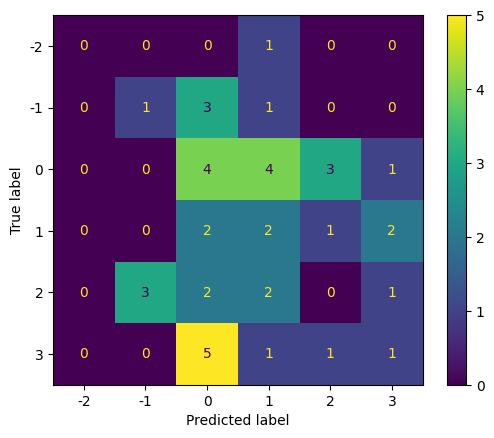

In [917]:
disp = ConfusionMatrixDisplay.from_estimator(dum, xTest, yTest)
plt.show()

# KNeighborsClassifier

In [918]:
from sklearn.neighbors import KNeighborsClassifier

In [ ]:
knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(xTrain, yTrain)
knnPred = knn.predict(xTest)


print(classification_report(yTest, knnPred))

              precision    recall  f1-score   support

          -2       0.00      0.00      0.00         1
          -1       0.60      0.60      0.60         5
           0       0.82      0.75      0.78        12
           1       0.64      1.00      0.78         7
           2       0.50      0.75      0.60         8
           3       1.00      0.25      0.40         8

    accuracy                           0.66        41
   macro avg       0.59      0.56      0.53        41
weighted avg       0.71      0.66      0.63        41



c:\Users\jonas\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\metrics\_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
c:\Users\jonas\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\metrics\_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
c:\Users\jonas\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\metrics\_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, mo

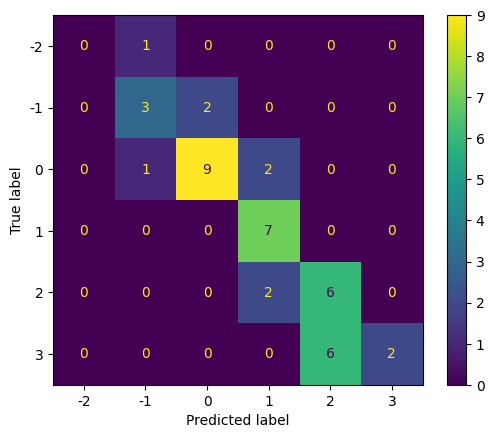

In [920]:
disp = ConfusionMatrixDisplay.from_estimator(knn, xTest, yTest)
plt.show()

A lot better, but still a lot of wrong classifications

hyperparam tuning

In [921]:
from sklearn.model_selection import GridSearchCV

In [922]:
# dictionary of the parameters we want to tune
hyper_params = {
    'n_neighbors': range(1,16),
    'p': range(1, 5)
}


# grid search finds optimal combination of n and p
grid = GridSearchCV(KNeighborsClassifier(), hyper_params)
grid.fit(xTrain, yTrain)

c:\Users\jonas\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\model_selection\_split.py:776: UserWarning: The least populated class in y has only 2 members, which is less than n_splits=5.
  warnings.warn(


GridSearchCV(estimator=KNeighborsClassifier(),
             param_grid={'n_neighbors': range(1, 16), 'p': range(1, 5)})

In [924]:
print(f"optimal # of neighbours: {grid.best_params_['n_neighbors']} optimal p: {grid.best_params_['p']}")

optimal # of neighbours: 1 optimal p: 3


In [926]:
# fit model with the model with new params
knn_model = KNeighborsClassifier(n_neighbors = grid.best_params_['n_neighbors'], 
                                 p=grid.best_params_['p'])
knn_model.fit(xTrain, yTrain)

knn2Pred = knn_model.predict(xTest)

print(classification_report(yTest, knn2Pred))

              precision    recall  f1-score   support

          -2       0.00      0.00      0.00         1
          -1       0.71      1.00      0.83         5
           0       0.91      0.83      0.87        12
           1       0.75      0.86      0.80         7
           2       1.00      0.75      0.86         8
           3       0.89      1.00      0.94         8

    accuracy                           0.85        41
   macro avg       0.71      0.74      0.72        41
weighted avg       0.85      0.85      0.84        41



c:\Users\jonas\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\metrics\_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
c:\Users\jonas\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\metrics\_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
c:\Users\jonas\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\metrics\_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, mo

Accuracy went up from 0.66 to 0.85

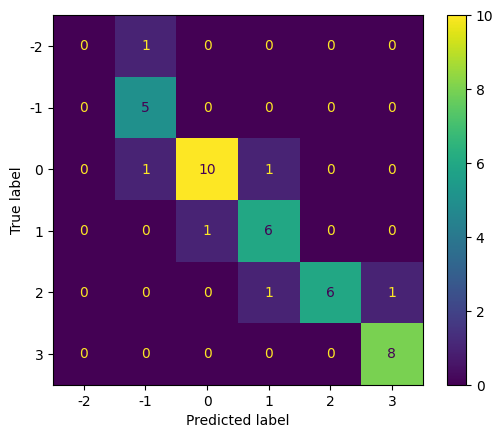

In [ ]:
disp = ConfusionMatrixDisplay.from_estimator(knn_model, xTest, yTest)
plt.show()

# Logistic regression

In [ ]:
from sklearn.linear_model import LogisticRegression

In [ ]:
# initialize model with multinomial because its multiclass classification
lr = LogisticRegression(multi_class='multinomial', max_iter=1000)
lr.fit(xTrain, yTrain)

lrPred = lr.predict(xTest)

print(classification_report(yTest, lrPred))

              precision    recall  f1-score   support

          -2       0.00      0.00      0.00         1
          -1       0.57      0.80      0.67         5
           0       0.89      0.67      0.76        12
           1       0.58      1.00      0.74         7
           2       0.80      0.50      0.62         8
           3       0.88      0.88      0.88         8

    accuracy                           0.73        41
   macro avg       0.62      0.64      0.61        41
weighted avg       0.76      0.73      0.72        41



c:\Users\jonas\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\linear_model\_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(
c:\Users\jonas\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\metrics\_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
c:\Users\jonas\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\metrics\_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} 

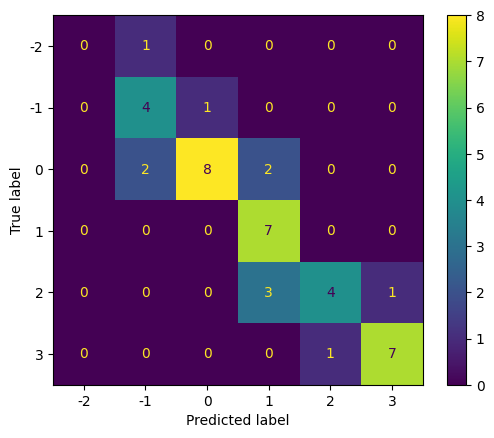

In [937]:
disp = ConfusionMatrixDisplay.from_estimator(lr, xTest, yTest)
plt.show()

Not as good as Kneighbours with tuned hyperparameters

# Gaussian Naive Bayes

In [ ]:
from sklearn.naive_bayes import GaussianNB

In [ ]:
# initialize model
gnb = GaussianNB()

# fit to data
gnb.fit(xTrain, yTrain)

# predict on test set
gnbPred = gnb.predict(xTest)
print(classification_report(yTest, gnbPred))

              precision    recall  f1-score   support

          -2       0.00      0.00      0.00         1
          -1       0.83      1.00      0.91         5
           0       1.00      1.00      1.00        12
           1       1.00      0.86      0.92         7
           2       0.89      1.00      0.94         8
           3       1.00      1.00      1.00         8

    accuracy                           0.95        41
   macro avg       0.79      0.81      0.80        41
weighted avg       0.93      0.95      0.94        41



c:\Users\jonas\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\metrics\_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
c:\Users\jonas\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\metrics\_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
c:\Users\jonas\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\metrics\_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, mo

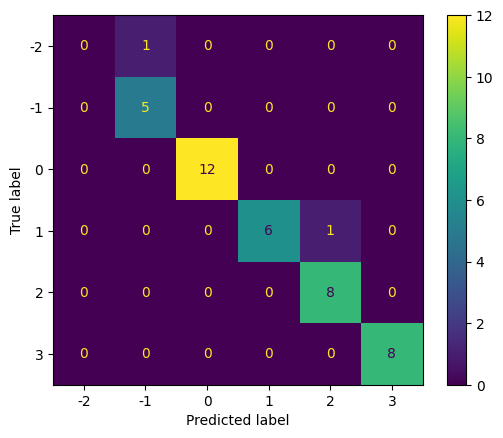

In [ ]:
disp = ConfusionMatrixDisplay.from_estimator(gnb, xTest, yTest)
plt.show()

Gaussian Naive Bayes had the best accuracy of the models, it only misclassified 2 samples

None of the model were able to correctly classify the one sample with Symboling -2, which is understandable given the fact that were only 3 of them in the whole dataset

# conclusion

It is not feasible to accurately predict samples with symboling -2 because how few there are of them in the data. The other labels we were able to predict most of the time

I dont think the unsupervised learning produced much meaningful results, but the supervised learning produced some pretty good results. And we were able to predict with good accuracy. Also in all the models except the dummy classifier we were only off by 1 when we predicted wrong. Meaning we never predicted that a sample with true label 0 had a label of -2, 2 or 3, only -1, 0 or 1 etc